In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
!nvidia-smi

Sat May 16 13:32:20 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    Off |   00000000:05:00.0 Off |                    0 |
| N/A   28C    P0             46W /  600W |       0MiB /  97887MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [3]:
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 36.8 MB/s eta 0:00:00


In [4]:
from pathlib import Path
import pandas as pd
from collections import Counter
import shutil
import random
from PIL import Image
import matplotlib.pyplot as plt

from ultralytics import YOLO, RTDETR

BASE_DIR = Path("/content/drive/MyDrive/DIS_PROJESI_007")

DENTEX_DATASET = BASE_DIR / "data_prepared" / "dentex_yolo_3class"
DATA_YAML = DENTEX_DATASET / "data.yaml"

RUNS_DIR = BASE_DIR / "runs" / "dentex"
RESULTS_DIR = BASE_DIR / "results" / "dentex_training"
FINAL_MODELS_DIR = BASE_DIR / "final_models" / "dentex"

RUNS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FINAL_MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("DENTEX dataset:", DENTEX_DATASET)
print("data.yaml:", DATA_YAML)
print("data.yaml var mı?:", DATA_YAML.exists())
print("runs dir:", RUNS_DIR)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
DENTEX dataset: /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/dentex_yolo_3class
data.yaml: /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/dentex_yolo_3class/data.yaml
data.yaml var mı?: True
runs dir: /content/drive/MyDrive/DIS_PROJESI_007/runs/dentex


In [5]:
print(DATA_YAML.read_text())

path: /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/dentex_yolo_3class
train: images/train
val: images/val
test: images/test

names:
  0: caries
  1: deep_caries
  2: periapical_lesion


In [6]:
def count_split(split):
    img_dir = DENTEX_DATASET / "images" / split
    label_dir = DENTEX_DATASET / "labels" / split

    img_count = len(list(img_dir.glob("*")))
    label_count = len(list(label_dir.glob("*.txt")))

    return img_count, label_count

rows = []

for split in ["train", "val", "test"]:
    img_count, label_count = count_split(split)
    rows.append({
        "split": split,
        "images": img_count,
        "labels": label_count
    })

df_split_counts = pd.DataFrame(rows)
df_split_counts

,split,images,labels
0,train,463,463
1,val,119,119
2,test,80,80


In [7]:
class_names = {
    0: "caries",
    1: "deep_caries",
    2: "periapical_lesion"
}

counter = Counter()

for label_path in (DENTEX_DATASET / "labels").rglob("*.txt"):
    lines = label_path.read_text().strip().splitlines()

    for line in lines:
        if line.strip() == "":
            continue

        cls_id = int(line.split()[0])
        counter[cls_id] += 1

df_class_counts = pd.DataFrame([
    {
        "class_id": cls_id,
        "class_name": class_names[cls_id],
        "count": count
    }
    for cls_id, count in sorted(counter.items())
])

df_class_counts

,class_id,class_name,count
0,0,caries,2189
1,1,deep_caries,578
2,2,periapical_lesion,158


In [8]:
def count_classes_by_split(dataset_dir):
    rows = []

    for split in ["train", "val", "test"]:
        label_dir = dataset_dir / "labels" / split
        split_counter = Counter()

        for label_path in label_dir.glob("*.txt"):
            lines = label_path.read_text().strip().splitlines()

            for line in lines:
                if line.strip() == "":
                    continue

                cls_id = int(line.split()[0])
                split_counter[cls_id] += 1

        for cls_id, count in sorted(split_counter.items()):
            rows.append({
                "split": split,
                "class_id": cls_id,
                "class_name": class_names[cls_id],
                "count": count
            })

    return pd.DataFrame(rows)

df_split_class_counts = count_classes_by_split(DENTEX_DATASET)
df_split_class_counts

,split,class_id,class_name,count
0,train,0,caries,1549
1,train,1,deep_caries,387
2,train,2,periapical_lesion,107
3,val,0,caries,392
4,val,1,deep_caries,110
5,val,2,periapical_lesion,35
6,test,0,caries,248
7,test,1,deep_caries,81
8,test,2,periapical_lesion,16


In [9]:
experiments = [
    {
        "model_name": "YOLOv8n",
        "model_type": "yolo",
        "weights": "yolov8n.pt",
        "imgsz": 640,
        "epochs": 30,
        "batch": 8,
        "run_name": "yolov8n_640_30ep"
    },
    {
        "model_name": "YOLOv8s",
        "model_type": "yolo",
        "weights": "yolov8s.pt",
        "imgsz": 768,
        "epochs": 30,
        "batch": 8,
        "run_name": "yolov8s_768_30ep"
    },
    {
        "model_name": "YOLOv8m",
        "model_type": "yolo",
        "weights": "yolov8m.pt",
        "imgsz": 768,
        "epochs": 30,
        "batch": 4,
        "run_name": "yolov8m_768_30ep"
    },
    {
        "model_name": "YOLO11s",
        "model_type": "yolo",
        "weights": "yolo11s.pt",
        "imgsz": 768,
        "epochs": 30,
        "batch": 8,
        "run_name": "yolo11s_768_30ep"
    },
    {
        "model_name": "RT-DETR-l",
        "model_type": "rtdetr",
        "weights": "rtdetr-l.pt",
        "imgsz": 640,
        "epochs": 30,
        "batch": 4,
        "run_name": "rtdetr_l_640_30ep"
    }
]

pd.DataFrame(experiments)

,model_name,model_type,weights,imgsz,epochs,batch,run_name
0,YOLOv8n,yolo,yolov8n.pt,640,30,8,yolov8n_640_30ep
1,YOLOv8s,yolo,yolov8s.pt,768,30,8,yolov8s_768_30ep
2,YOLOv8m,yolo,yolov8m.pt,768,30,4,yolov8m_768_30ep
3,YOLO11s,yolo,yolo11s.pt,768,30,8,yolo11s_768_30ep
4,RT-DETR-l,rtdetr,rtdetr-l.pt,640,30,4,rtdetr_l_640_30ep


In [10]:
def load_model(exp):
    if exp["model_type"] == "rtdetr":
        return RTDETR(exp["weights"])
    else:
        return YOLO(exp["weights"])


def train_and_evaluate_detection(exp):
    print("\n" + "=" * 120)
    print("DENEY BAŞLIYOR:", exp["run_name"])
    print("Model:", exp["model_name"])
    print("Weights:", exp["weights"])
    print("imgsz:", exp["imgsz"], "| epochs:", exp["epochs"], "| batch:", exp["batch"])
    print("=" * 120)

    model = load_model(exp)

    try:
        model.train(
            data=str(DATA_YAML),
            epochs=exp["epochs"],
            imgsz=exp["imgsz"],
            batch=exp["batch"],
            device=0,
            project=str(RUNS_DIR),
            name=exp["run_name"],
            exist_ok=True,
            patience=10,
            workers=2,
            cache=False
        )

        exp_dir = RUNS_DIR / exp["run_name"]
        best_model_path = exp_dir / "weights" / "best.pt"

        print("\nBest model path:", best_model_path)
        print("Best var mı?:", best_model_path.exists())

        if not best_model_path.exists():
            raise FileNotFoundError(f"best.pt bulunamadı: {best_model_path}")

        if exp["model_type"] == "rtdetr":
            best_model = RTDETR(str(best_model_path))
        else:
            best_model = YOLO(str(best_model_path))

        test_name = exp["run_name"] + "_test"

        test_metrics = best_model.val(
            data=str(DATA_YAML),
            split="test",
            imgsz=exp["imgsz"],
            batch=exp["batch"],
            device=0,
            project=str(RUNS_DIR),
            name=test_name,
            exist_ok=True
        )

        summary = {
            "status": "ok",
            "model": exp["model_name"],
            "model_type": exp["model_type"],
            "weights": exp["weights"],
            "run_name": exp["run_name"],
            "imgsz": exp["imgsz"],
            "epochs": exp["epochs"],
            "batch": exp["batch"],
            "precision": float(test_metrics.box.mp),
            "recall": float(test_metrics.box.mr),
            "mAP50": float(test_metrics.box.map50),
            "mAP50-95": float(test_metrics.box.map),
            "best_model_path": str(best_model_path),
            "error": ""
        }

        print("\nTEST SONUCU:")
        display(pd.DataFrame([summary]))

        return summary

    except Exception as e:
        print("\nHATA OLUŞTU:", exp["run_name"])
        print(str(e))

        summary = {
            "status": "failed",
            "model": exp["model_name"],
            "model_type": exp["model_type"],
            "weights": exp["weights"],
            "run_name": exp["run_name"],
            "imgsz": exp["imgsz"],
            "epochs": exp["epochs"],
            "batch": exp["batch"],
            "precision": None,
            "recall": None,
            "mAP50": None,
            "mAP50-95": None,
            "best_model_path": "",
            "error": str(e)
        }

        return summary

In [11]:
all_results = []

for exp in experiments:
    result = train_and_evaluate_detection(exp)
    all_results.append(result)

    # Her deneyden sonra ara kayıt alalım
    df_temp = pd.DataFrame(all_results)
    temp_csv = RESULTS_DIR / "dentex_model_comparison_running.csv"
    df_temp.to_csv(temp_csv, index=False)
    print("Ara sonuç kaydedildi:", temp_csv)

df_all_results = pd.DataFrame(all_results)
df_all_results


DENEY BAŞLIYOR: yolov8n_640_30ep
Model: YOLOv8n
Weights: yolov8n.pt
imgsz: 640 | epochs: 30 | batch: 8
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/DIS_PROJESI_007/data_prepared/dentex_yolo_3class/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=

,status,model,model_type,weights,run_name,imgsz,epochs,batch,precision,recall,mAP50,mAP50-95,best_model_path,error
0,ok,YOLOv8n,yolo,yolov8n.pt,yolov8n_640_30ep,640,30,8,0.005913,0.404039,0.014097,0.004037,/content/drive/MyDrive/DIS_PROJESI_007/runs/de...,


Ara sonuç kaydedildi: /content/drive/MyDrive/DIS_PROJESI_007/results/dentex_training/dentex_model_comparison_running.csv

DENEY BAŞLIYOR: yolov8s_768_30ep
Model: YOLOv8s
Weights: yolov8s.pt
imgsz: 768 | epochs: 30 | batch: 8
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/DIS_PROJESI_007/data_prepared/dentex_yolo_3class/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgs

,status,model,model_type,weights,run_name,imgsz,epochs,batch,precision,recall,mAP50,mAP50-95,best_model_path,error
0,ok,YOLOv8s,yolo,yolov8s.pt,yolov8s_768_30ep,768,30,8,0.014987,0.435874,0.015872,0.004526,/content/drive/MyDrive/DIS_PROJESI_007/runs/de...,


Ara sonuç kaydedildi: /content/drive/MyDrive/DIS_PROJESI_007/results/dentex_training/dentex_model_comparison_running.csv

DENEY BAŞLIYOR: yolov8m_768_30ep
Model: YOLOv8m
Weights: yolov8m.pt
imgsz: 768 | epochs: 30 | batch: 4
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/DIS_PROJESI_007/data_prepared/dentex_yolo_3class/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgs

...

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      28/30      3.63G     0.7539     0.9482     0.2694         10        640: 100% ━━━━━━━━━━━━ 116/116 6.6it/s 17.5s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 33.3it/s 0.5s
                   all        119        537      0.686      0.166     0.0267    0.00697
EarlyStopping: Training stopped early as no improvement observed in last 10 epochs. Best results observed at epoch 18, best model saved as best.pt.
To update EarlyStopping(patience=10) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.

28 epochs completed in 0.137 hours.
Optimizer stripped from /content/drive/MyDrive/DIS_PROJESI_007/runs/dentex/rtdetr_l_640_30ep/weights/last.pt, 66.2MB
Optimizer stripped from /content/drive/MyDrive/DIS_PROJESI_007/runs/dentex/rtdetr_l_640_30ep/weights/best.pt, 66.2MB

Validating /content/drive/MyDrive/DIS_PROJESI_007/runs/dentex/rtdetr_l_640_30ep/weights/best.pt...
Ultralytics 8.4

,status,model,model_type,weights,run_name,imgsz,epochs,batch,precision,recall,mAP50,mAP50-95,best_model_path,error
0,ok,RT-DETR-l,rtdetr,rtdetr-l.pt,rtdetr_l_640_30ep,640,30,4,0.684156,0.133065,0.022853,0.005516,/content/drive/MyDrive/DIS_PROJESI_007/runs/de...,


Ara sonuç kaydedildi: /content/drive/MyDrive/DIS_PROJESI_007/results/dentex_training/dentex_model_comparison_running.csv


,status,model,model_type,weights,run_name,imgsz,epochs,batch,precision,recall,mAP50,mAP50-95,best_model_path,error
0,ok,YOLOv8n,yolo,yolov8n.pt,yolov8n_640_30ep,640,30,8,0.005913,0.404039,0.014097,0.004037,/content/drive/MyDrive/DIS_PROJESI_007/runs/de...,
1,ok,YOLOv8s,yolo,yolov8s.pt,yolov8s_768_30ep,768,30,8,0.014987,0.435874,0.015872,0.004526,/content/drive/MyDrive/DIS_PROJESI_007/runs/de...,
2,ok,YOLOv8m,yolo,yolov8m.pt,yolov8m_768_30ep,768,30,4,0.006297,0.389171,0.013507,0.003940,/content/drive/MyDrive/DIS_PROJESI_007/runs/de...,
3,ok,YOLO11s,yolo,yolo11s.pt,yolo11s_768_30ep,768,30,8,0.017453,0.448302,0.021067,0.006000,/content/drive/MyDrive/DIS_PROJESI_007/runs/de...,
4,ok,RT-DETR-l,rtdetr,rtdetr-l.pt,rtdetr_l_640_30ep,640,30,4,0.684156,0.133065,0.022853,0.005516,/content/drive/MyDrive/DIS_PROJESI_007/runs/de...,


In [12]:
df_success = df_all_results[df_all_results["status"] == "ok"].copy()

df_success

,status,model,model_type,weights,run_name,imgsz,epochs,batch,precision,recall,mAP50,mAP50-95,best_model_path,error
0,ok,YOLOv8n,yolo,yolov8n.pt,yolov8n_640_30ep,640,30,8,0.005913,0.404039,0.014097,0.004037,/content/drive/MyDrive/DIS_PROJESI_007/runs/de...,
1,ok,YOLOv8s,yolo,yolov8s.pt,yolov8s_768_30ep,768,30,8,0.014987,0.435874,0.015872,0.004526,/content/drive/MyDrive/DIS_PROJESI_007/runs/de...,
2,ok,YOLOv8m,yolo,yolov8m.pt,yolov8m_768_30ep,768,30,4,0.006297,0.389171,0.013507,0.003940,/content/drive/MyDrive/DIS_PROJESI_007/runs/de...,
3,ok,YOLO11s,yolo,yolo11s.pt,yolo11s_768_30ep,768,30,8,0.017453,0.448302,0.021067,0.006000,/content/drive/MyDrive/DIS_PROJESI_007/runs/de...,
4,ok,RT-DETR-l,rtdetr,rtdetr-l.pt,rtdetr_l_640_30ep,640,30,4,0.684156,0.133065,0.022853,0.005516,/content/drive/MyDrive/DIS_PROJESI_007/runs/de...,


In [13]:
df_results_sorted = df_success.sort_values("mAP50", ascending=False)
df_results_sorted

,status,model,model_type,weights,run_name,imgsz,epochs,batch,precision,recall,mAP50,mAP50-95,best_model_path,error
4,ok,RT-DETR-l,rtdetr,rtdetr-l.pt,rtdetr_l_640_30ep,640,30,4,0.684156,0.133065,0.022853,0.005516,/content/drive/MyDrive/DIS_PROJESI_007/runs/de...,
3,ok,YOLO11s,yolo,yolo11s.pt,yolo11s_768_30ep,768,30,8,0.017453,0.448302,0.021067,0.006000,/content/drive/MyDrive/DIS_PROJESI_007/runs/de...,
1,ok,YOLOv8s,yolo,yolov8s.pt,yolov8s_768_30ep,768,30,8,0.014987,0.435874,0.015872,0.004526,/content/drive/MyDrive/DIS_PROJESI_007/runs/de...,
0,ok,YOLOv8n,yolo,yolov8n.pt,yolov8n_640_30ep,640,30,8,0.005913,0.404039,0.014097,0.004037,/content/drive/MyDrive/DIS_PROJESI_007/runs/de...,
2,ok,YOLOv8m,yolo,yolov8m.pt,yolov8m_768_30ep,768,30,4,0.006297,0.389171,0.013507,0.003940,/content/drive/MyDrive/DIS_PROJESI_007/runs/de...,


In [14]:
compare_csv = RESULTS_DIR / "dentex_model_comparison_first_round_30ep.csv"

df_results_sorted.to_csv(compare_csv, index=False)

print("Karşılaştırma kaydedildi:")
print(compare_csv)

Karşılaştırma kaydedildi:
/content/drive/MyDrive/DIS_PROJESI_007/results/dentex_training/dentex_model_comparison_first_round_30ep.csv


In [15]:
best_row = df_results_sorted.iloc[0]

best_model_name = best_row["model"]
best_model_type = best_row["model_type"]
best_run_name = best_row["run_name"]
best_model_path = Path(best_row["best_model_path"])

print("İlk tur en iyi DENTEX modeli:")
print("Model:", best_model_name)
print("Model type:", best_model_type)
print("Run:", best_run_name)
print("Precision:", best_row["precision"])
print("Recall:", best_row["recall"])
print("mAP50:", best_row["mAP50"])
print("mAP50-95:", best_row["mAP50-95"])
print("Best path:", best_model_path)

İlk tur en iyi DENTEX modeli:
Model: RT-DETR-l
Model type: rtdetr
Run: rtdetr_l_640_30ep
Precision: 0.6841558931184105
Recall: 0.13306451612903225
mAP50: 0.02285341490121162
mAP50-95: 0.005516090383804106
Best path: /content/drive/MyDrive/DIS_PROJESI_007/runs/dentex/rtdetr_l_640_30ep/weights/best.pt


In [16]:
final_model_path = FINAL_MODELS_DIR / f"{best_run_name}_best.pt"

shutil.copy2(best_model_path, final_model_path)

print("Final model kopyalandı:")
print(final_model_path)

Final model kopyalandı:
/content/drive/MyDrive/DIS_PROJESI_007/final_models/dentex/rtdetr_l_640_30ep_best.pt


In [17]:
if best_model_type == "rtdetr":
    best_model = RTDETR(str(best_model_path))
else:
    best_model = YOLO(str(best_model_path))

split_summaries = []

for split in ["train", "val", "test"]:
    print("\n" + "=" * 80)
    print("Değerlendirilen split:", split)
    print("=" * 80)

    metrics = best_model.val(
        data=str(DATA_YAML),
        split=split,
        imgsz=int(best_row["imgsz"]),
        batch=int(best_row["batch"]),
        device=0,
        project=str(RUNS_DIR),
        name=f"{best_run_name}_{split}_check",
        exist_ok=True
    )

    split_summaries.append({
        "model": best_model_name,
        "run_name": best_run_name,
        "split": split,
        "precision": float(metrics.box.mp),
        "recall": float(metrics.box.mr),
        "mAP50": float(metrics.box.map50),
        "mAP50-95": float(metrics.box.map)
    })

df_best_split_metrics = pd.DataFrame(split_summaries)
df_best_split_metrics


Değerlendirilen split: train
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
rt-detr-l summary: 310 layers, 31,989,905 parameters, 0 gradients, 103.4 GFLOPs
val: Fast image access ✅ (ping: 0.1±0.0 ms, read: 2431.8±530.8 MB/s, size: 4871.2 KB)
val: Scanning /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/dentex_yolo_3class/labels/train.cache... 463 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 463/463 194.2Mit/s 0.0s
train: /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/dentex_yolo_3class/images/train/train_377.png: 1 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 116/116 35.2it/s 3.3s
                   all        463       2042      0.687      0.144     0.0281    0.00762
                caries        438       1548     0.0609      0.433     0.0668     0.0186
           deep_caries        223        387          1

,model,run_name,split,precision,recall,mAP50,mAP50-95
0,RT-DETR-l,rtdetr_l_640_30ep,train,0.686963,0.144272,0.028071,0.007621
1,RT-DETR-l,rtdetr_l_640_30ep,val,0.687210,0.142076,0.029140,0.007690
2,RT-DETR-l,rtdetr_l_640_30ep,test,0.684156,0.133065,0.022853,0.005516


In [18]:
split_metrics_csv = RESULTS_DIR / f"{best_run_name}_train_val_test_metrics.csv"

df_best_split_metrics.to_csv(split_metrics_csv, index=False)

print("Kaydedildi:", split_metrics_csv)

Kaydedildi: /content/drive/MyDrive/DIS_PROJESI_007/results/dentex_training/rtdetr_l_640_30ep_train_val_test_metrics.csv


In [19]:
pred_name = best_run_name + "_predictions_conf50"

pred_result = best_model.predict(
    source=str(DENTEX_DATASET / "images" / "test"),
    imgsz=int(best_row["imgsz"]),
    conf=0.50,
    device=0,
    project=str(RUNS_DIR),
    name=pred_name,
    exist_ok=True,
    save=True
)

PRED_DIR = RUNS_DIR / pred_name

print("Prediction klasörü:", PRED_DIR)
print("Var mı?:", PRED_DIR.exists())


image 1/80 /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/dentex_yolo_3class/images/test/train_101.png: 640x640 (no detections), 12.3ms
image 2/80 /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/dentex_yolo_3class/images/test/train_102.png: 640x640 (no detections), 12.6ms
image 3/80 /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/dentex_yolo_3class/images/test/train_116.png: 640x640 (no detections), 12.7ms
image 4/80 /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/dentex_yolo_3class/images/test/train_128.png: 640x640 (no detections), 12.6ms
image 5/80 /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/dentex_yolo_3class/images/test/train_135.png: 640x640 (no detections), 12.6ms
image 6/80 /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/dentex_yolo_3class/images/test/train_137.png: 640x640 (no detections), 12.6ms
image 7/80 /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/dentex_yolo_3class/images/test/train_138.png: 640x640 (no detections), 12.6ms
image

In [20]:
pred_images = list(PRED_DIR.glob("*.jpg")) + list(PRED_DIR.glob("*.png"))

print("Tahmin görsel sayısı:", len(pred_images))

if len(pred_images) > 0:
    sample_preds = random.sample(pred_images, min(8, len(pred_images)))

    for img_path in sample_preds:
        img = Image.open(img_path).convert("RGB")
        plt.figure(figsize=(14, 7))
        plt.imshow(img)
        plt.axis("off")
        plt.title(img_path.name)
        plt.show()
else:
    print("Tahmin görseli bulunamadı.")

Output hidden; open in https://colab.research.google.com to view.

In [21]:
print("DENTEX ilk tur model karşılaştırması tamamlandı.")
print("=" * 100)

print("Karşılaştırma CSV:", compare_csv)
print("En iyi model:", best_model_name)
print("En iyi run:", best_run_name)
print("Final model:", final_model_path)

display(df_results_sorted)
display(df_best_split_metrics)

DENTEX ilk tur model karşılaştırması tamamlandı.
Karşılaştırma CSV: /content/drive/MyDrive/DIS_PROJESI_007/results/dentex_training/dentex_model_comparison_first_round_30ep.csv
En iyi model: RT-DETR-l
En iyi run: rtdetr_l_640_30ep
Final model: /content/drive/MyDrive/DIS_PROJESI_007/final_models/dentex/rtdetr_l_640_30ep_best.pt


,status,model,model_type,weights,run_name,imgsz,epochs,batch,precision,recall,mAP50,mAP50-95,best_model_path,error
4,ok,RT-DETR-l,rtdetr,rtdetr-l.pt,rtdetr_l_640_30ep,640,30,4,0.684156,0.133065,0.022853,0.005516,/content/drive/MyDrive/DIS_PROJESI_007/runs/de...,
3,ok,YOLO11s,yolo,yolo11s.pt,yolo11s_768_30ep,768,30,8,0.017453,0.448302,0.021067,0.006000,/content/drive/MyDrive/DIS_PROJESI_007/runs/de...,
1,ok,YOLOv8s,yolo,yolov8s.pt,yolov8s_768_30ep,768,30,8,0.014987,0.435874,0.015872,0.004526,/content/drive/MyDrive/DIS_PROJESI_007/runs/de...,
0,ok,YOLOv8n,yolo,yolov8n.pt,yolov8n_640_30ep,640,30,8,0.005913,0.404039,0.014097,0.004037,/content/drive/MyDrive/DIS_PROJESI_007/runs/de...,
2,ok,YOLOv8m,yolo,yolov8m.pt,yolov8m_768_30ep,768,30,4,0.006297,0.389171,0.013507,0.003940,/content/drive/MyDrive/DIS_PROJESI_007/runs/de...,


,model,run_name,split,precision,recall,mAP50,mAP50-95
0,RT-DETR-l,rtdetr_l_640_30ep,train,0.686963,0.144272,0.028071,0.007621
1,RT-DETR-l,rtdetr_l_640_30ep,val,0.687210,0.142076,0.029140,0.007690
2,RT-DETR-l,rtdetr_l_640_30ep,test,0.684156,0.133065,0.022853,0.005516


In [22]:
from pathlib import Path
import pandas as pd
import shutil
from ultralytics import RTDETR

BASE_DIR = Path("/content/drive/MyDrive/DIS_PROJESI_007")

DENTEX_DATASET = BASE_DIR / "data_prepared" / "dentex_yolo_3class"
DATA_YAML = DENTEX_DATASET / "data.yaml"

RUNS_DIR = BASE_DIR / "runs" / "dentex"
RESULTS_DIR = BASE_DIR / "results" / "dentex_training"
FINAL_MODELS_DIR = BASE_DIR / "final_models" / "dentex"

FIRST_ROUND_BEST = FINAL_MODELS_DIR / "rtdetr_l_640_30ep_best.pt"

print("İlk tur RT-DETR best model:")
print(FIRST_ROUND_BEST)
print("Var mı?:", FIRST_ROUND_BEST.exists())

İlk tur RT-DETR best model:
/content/drive/MyDrive/DIS_PROJESI_007/final_models/dentex/rtdetr_l_640_30ep_best.pt
Var mı?: True


In [23]:
final_exp = {
    "model_name": "RT-DETR-l",
    "model_type": "rtdetr",
    "weights": str(FIRST_ROUND_BEST),
    "imgsz": 768,
    "epochs": 100,
    "batch": 4,
    "run_name": "rtdetr_l_768_100ep_finetune"
}

final_exp

{'model_name': 'RT-DETR-l',
 'model_type': 'rtdetr',
 'weights': '/content/drive/MyDrive/DIS_PROJESI_007/final_models/dentex/rtdetr_l_640_30ep_best.pt',
 'imgsz': 768,
 'epochs': 100,
 'batch': 4,
 'run_name': 'rtdetr_l_768_100ep_finetune'}

In [24]:
final_exp = {
    "model_name": "RT-DETR-l",
    "model_type": "rtdetr",
    "weights": str(FIRST_ROUND_BEST),
    "imgsz": 768,
    "epochs": 100,
    "batch": 2,
    "run_name": "rtdetr_l_768_100ep_finetune"
}

final_exp

{'model_name': 'RT-DETR-l',
 'model_type': 'rtdetr',
 'weights': '/content/drive/MyDrive/DIS_PROJESI_007/final_models/dentex/rtdetr_l_640_30ep_best.pt',
 'imgsz': 768,
 'epochs': 100,
 'batch': 2,
 'run_name': 'rtdetr_l_768_100ep_finetune'}

In [28]:
FINAL_EXP_DIR = RUNS_DIR / final_exp["run_name"]

print("Beklenen final deney klasörü:", FINAL_EXP_DIR)
print("Var mı?:", FINAL_EXP_DIR.exists())

if FINAL_EXP_DIR.exists():
    print("\nKlasör içeriği:")
    for p in FINAL_EXP_DIR.iterdir():
        print(p.name)
else:
    print("\nBu klasör bulunamadı.")
    print("Muhtemel nedenler:")
    print("1. 24. eğitim hücresi çalıştırılmadı veya yarıda kesildi.")
    print("2. final_exp['run_name'] farklıydı.")
    print("3. Eğitim başka klasör adıyla kaydedildi.")

Beklenen final deney klasörü: /content/drive/MyDrive/DIS_PROJESI_007/runs/dentex/rtdetr_l_768_100ep_finetune
Var mı?: False

Bu klasör bulunamadı.
Muhtemel nedenler:
1. 24. eğitim hücresi çalıştırılmadı veya yarıda kesildi.
2. final_exp['run_name'] farklıydı.
3. Eğitim başka klasör adıyla kaydedildi.


In [30]:
final_exp = {
    "model_name": "RT-DETR-l",
    "model_type": "rtdetr",
    "weights": str(FIRST_ROUND_BEST),
    "imgsz": 768,
    "epochs": 100,
    "batch": 4,
    "run_name": "rtdetr_l_768_100ep_finetune_batch4"
}

final_exp

{'model_name': 'RT-DETR-l',
 'model_type': 'rtdetr',
 'weights': '/content/drive/MyDrive/DIS_PROJESI_007/final_models/dentex/rtdetr_l_640_30ep_best.pt',
 'imgsz': 768,
 'epochs': 100,
 'batch': 4,
 'run_name': 'rtdetr_l_768_100ep_finetune_batch4'}

In [31]:
final_model = RTDETR(final_exp["weights"])

final_model.train(
    data=str(DATA_YAML),
    epochs=final_exp["epochs"],
    imgsz=final_exp["imgsz"],
    batch=final_exp["batch"],
    device=0,
    project=str(RUNS_DIR),
    name=final_exp["run_name"],
    exist_ok=True,
    patience=25,
    workers=2,
    cache=False,
    optimizer="AdamW",
    lr0=0.0001,
    weight_decay=0.0005
)

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/DIS_PROJESI_007/data_prepared/dentex_yolo_3class/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=768, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/DIS_PROJESI_007/final_models/dentex/rtdetr_l_640_30ep_b

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      1/100      4.57G      2.562     0.1864      1.604         34        768: 100% ━━━━━━━━━━━━ 116/116 6.4it/s 18.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 6.9it/s 2.2s
                   all        119        537   0.000196        0.2   0.000171   5.95e-05

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      2/100      4.85G      1.928     0.8335      1.273         34        768: 1% ──────────── 1/116 2.4it/s 0.2s<48.0s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      2/100      4.86G      2.197     0.4522      1.518         10        768: 100% ━━━━━━━━━━━━ 116/116 8.9it/s 13.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 28.6it/s 0.5s
                   all        119        537    0.00105     0.0952   0.000875   0.000119

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      3/100      4.86G      1.993     0.4351     0.9604         32        768: 1% ──────────── 1/116 2.6it/s 0.2s<44.3s

...

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


     67/100      4.86G     0.8055     0.9682     0.2346         28        768: 100% ━━━━━━━━━━━━ 116/116 6.4it/s 18.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 27.8it/s 0.5s
                   all        119        537       0.35      0.101     0.0174    0.00492

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
     68/100      4.86G     0.8174     0.9546     0.2305         26        768: 1% ──────────── 1/116 2.3it/s 0.2s<49.7s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


     68/100      4.86G     0.8085     0.9574     0.2379         40        768: 100% ━━━━━━━━━━━━ 116/116 6.4it/s 18.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 29.4it/s 0.5s
                   all        119        537      0.686      0.085     0.0172    0.00477
EarlyStopping: Training stopped early as no improvement observed in last 25 epochs. Best results observed at epoch 43, best model saved as best.pt.
To update EarlyStopping(patience=25) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.

68 epochs completed in 0.330 hours.
Optimizer stripped from /content/drive/MyDrive/DIS_PROJESI_007/runs/dentex/rtdetr_l_768_100ep_finetune_batch4/weights/last.pt, 66.3MB
Optimizer stripped from /content/drive/MyDrive/DIS_PROJESI_007/runs/dentex/rtdetr_l_768_100ep_finetune_batch4/weights/best.pt, 66.3MB

Validating /content/drive/MyDrive/DIS_PROJESI_007/runs/dentex/rtdetr_l_768_100ep

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a6dd2f33680>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [32]:
FINAL_EXP_DIR = RUNS_DIR / final_exp["run_name"]

print("Final deney klasörü:", FINAL_EXP_DIR)
print("Var mı?:", FINAL_EXP_DIR.exists())

if FINAL_EXP_DIR.exists():
    print("\nKlasör içeriği:")
    for p in FINAL_EXP_DIR.iterdir():
        print(p.name)
else:
    print("Klasör bulunamadı. 24. hücre tamamlanmamış veya run_name farklı olabilir.")

Final deney klasörü: /content/drive/MyDrive/DIS_PROJESI_007/runs/dentex/rtdetr_l_768_100ep_finetune_batch4
Var mı?: True

Klasör içeriği:
weights
args.yaml
labels.jpg
train_batch0.jpg
train_batch1.jpg
train_batch2.jpg
results.csv
val_batch0_labels.jpg
val_batch0_pred.jpg
val_batch1_labels.jpg
val_batch2_labels.jpg
val_batch1_pred.jpg
val_batch2_pred.jpg
BoxPR_curve.png
BoxF1_curve.png
BoxP_curve.png
BoxR_curve.png
confusion_matrix_normalized.png
confusion_matrix.png
results.png


In [33]:
final_results_csv = FINAL_EXP_DIR / "results.csv"

print("results.csv var mı?:", final_results_csv.exists())
print("results.csv:", final_results_csv)

df_final_results = pd.read_csv(final_results_csv)
df_final_results.tail(10)

results.csv var mı?: True
results.csv: /content/drive/MyDrive/DIS_PROJESI_007/runs/dentex/rtdetr_l_768_100ep_finetune_batch4/results.csv


,epoch,time,train/giou_loss,train/cls_loss,train/l1_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/giou_loss,val/cls_loss,val/l1_loss,lr/pg0,lr/pg1,lr/pg2
58,59,1031.18,0.80168,0.97342,0.24372,0.68621,0.08418,0.01783,0.00479,0.70976,1.11505,0.28639,0.000043,0.000043,0.000043
59,60,1045.53,0.81510,0.95580,0.24620,0.68523,0.11224,0.01903,0.00512,0.72041,1.10976,0.28704,0.000042,0.000042,0.000042
60,61,1062.64,0.81129,0.95476,0.24069,0.68438,0.09864,0.01708,0.00472,0.69514,1.14356,0.28023,0.000041,0.000041,0.000041
61,62,1077.51,0.80344,0.97512,0.24586,0.68351,0.08588,0.01772,0.00494,0.70413,1.13797,0.28228,0.000040,0.000040,0.000040
62,63,1092.56,0.79375,0.96260,0.23638,0.68233,0.09694,0.01630,0.00477,0.69785,1.13716,0.27859,0.000039,0.000039,0.000039
63,64,1111.74,0.79673,0.96400,0.23716,0.68378,0.09184,0.01692,0.00482,0.70063,1.13552,0.28164,0.000038,0.000038,0.000038
64,65,1130.05,0.79323,0.98318,0.24220,0.68366,0.09014,0.01597,0.00435,0.70630,1.13423,0.28714,0.000037,0.000037,0.000037
65,66,1149.27,0.77871,0.98502,0.24643,0.34982,0.10374,0.01814,0.00503,0.69812,1.13623,0.28728,0.000036,0.000036,0.000036
66,67,1168.59,0.80553,0.96817,0.23461,0.35041,0.10119,0.01742,0.00492,0.69246,1.14334,0.28565,0.000035,0.000035,0.000035
67,68,1187.88,0.80855,0.95740,0.23791,0.68568,0.08503,0.01725,0.00477,0.69985,1.13623,0.28352,0.000034,0.000034,0.000034


In [34]:
final_best_model_path = FINAL_EXP_DIR / "weights" / "best.pt"
final_last_model_path = FINAL_EXP_DIR / "weights" / "last.pt"

print("best.pt var mı?:", final_best_model_path.exists())
print("last.pt var mı?:", final_last_model_path.exists())

print("\nBest model path:")
print(final_best_model_path)

print("\nLast model path:")
print(final_last_model_path)

best.pt var mı?: True
last.pt var mı?: True

Best model path:
/content/drive/MyDrive/DIS_PROJESI_007/runs/dentex/rtdetr_l_768_100ep_finetune_batch4/weights/best.pt

Last model path:
/content/drive/MyDrive/DIS_PROJESI_007/runs/dentex/rtdetr_l_768_100ep_finetune_batch4/weights/last.pt


In [35]:
final_best_model = RTDETR(str(final_best_model_path))

final_test_metrics = final_best_model.val(
    data=str(DATA_YAML),
    split="test",
    imgsz=final_exp["imgsz"],
    batch=final_exp["batch"],
    device=0,
    project=str(RUNS_DIR),
    name=final_exp["run_name"] + "_test",
    exist_ok=True
)

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
rt-detr-l summary: 310 layers, 31,989,905 parameters, 0 gradients, 103.4 GFLOPs
val: Fast image access ✅ (ping: 0.1±0.0 ms, read: 2460.9±145.3 MB/s, size: 4433.5 KB)
val: Scanning /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/dentex_yolo_3class/labels/test.cache... 80 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 80/80 37.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 20/20 22.3it/s 0.9s
                   all         80        345      0.681      0.086      0.016    0.00453
                caries         73        248     0.0418      0.258     0.0408     0.0117
           deep_caries         39         81          1          0    0.00561    0.00149
     periapical_lesion         12         16          1          0    0.00141   0.000424
Speed: 0.9ms preprocess, 6.2ms inference, 0.0ms 

In [36]:
df_final_metrics = pd.DataFrame([{
    "model": "RT-DETR-l",
    "run_name": final_exp["run_name"],
    "imgsz": final_exp["imgsz"],
    "epochs": final_exp["epochs"],
    "batch": final_exp["batch"],
    "precision": float(final_test_metrics.box.mp),
    "recall": float(final_test_metrics.box.mr),
    "mAP50": float(final_test_metrics.box.map50),
    "mAP50-95": float(final_test_metrics.box.map),
    "best_model_path": str(final_best_model_path)
}])

df_final_metrics

,model,run_name,imgsz,epochs,batch,precision,recall,mAP50,mAP50-95,best_model_path
0,RT-DETR-l,rtdetr_l_768_100ep_finetune_batch4,768,100,4,0.680612,0.086022,0.01595,0.004531,/content/drive/MyDrive/DIS_PROJESI_007/runs/de...


In [37]:
split_summaries = []

for split in ["train", "val", "test"]:
    print("\n" + "=" * 80)
    print("Split:", split)
    print("=" * 80)

    metrics = final_best_model.val(
        data=str(DATA_YAML),
        split=split,
        imgsz=final_exp["imgsz"],
        batch=final_exp["batch"],
        device=0,
        project=str(RUNS_DIR),
        name=f"{final_exp['run_name']}_{split}_check",
        exist_ok=True
    )

    split_summaries.append({
        "model": "RT-DETR-l",
        "run_name": final_exp["run_name"],
        "split": split,
        "precision": float(metrics.box.mp),
        "recall": float(metrics.box.mr),
        "mAP50": float(metrics.box.map50),
        "mAP50-95": float(metrics.box.map)
    })

df_final_split_metrics = pd.DataFrame(split_summaries)
df_final_split_metrics


Split: train
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
rt-detr-l summary: 310 layers, 31,989,905 parameters, 0 gradients, 103.4 GFLOPs
val: Fast image access ✅ (ping: 0.1±0.0 ms, read: 2233.9±407.5 MB/s, size: 4871.2 KB)
val: Scanning /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/dentex_yolo_3class/labels/train.cache... 463 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 463/463 176.5Mit/s 0.0s
train: /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/dentex_yolo_3class/images/train/train_377.png: 1 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 116/116 34.2it/s 3.4s
                   all        463       2042      0.686      0.111     0.0249     0.0076
                caries        438       1548     0.0581      0.333     0.0576     0.0173
           deep_caries        223        387          1          0     

,model,run_name,split,precision,recall,mAP50,mAP50-95
0,RT-DETR-l,rtdetr_l_768_100ep_finetune_batch4,train,0.686021,0.110896,0.024913,0.007598
1,RT-DETR-l,rtdetr_l_768_100ep_finetune_batch4,val,0.679302,0.148810,0.022101,0.008052
2,RT-DETR-l,rtdetr_l_768_100ep_finetune_batch4,test,0.680612,0.086022,0.015950,0.004531


In [38]:
first_round_best = {
    "model": "RT-DETR-l",
    "run_name": "rtdetr_l_640_30ep",
    "imgsz": 640,
    "epochs": 30,
    "batch": 4,
    "precision": 0.684156,
    "recall": 0.133065,
    "mAP50": 0.022853,
    "mAP50-95": 0.005516
}

df_compare_final = pd.concat([
    pd.DataFrame([first_round_best]),
    df_final_metrics[[
        "model", "run_name", "imgsz", "epochs", "batch",
        "precision", "recall", "mAP50", "mAP50-95"
    ]]
], ignore_index=True)

df_compare_final

,model,run_name,imgsz,epochs,batch,precision,recall,mAP50,mAP50-95
0,RT-DETR-l,rtdetr_l_640_30ep,640,30,4,0.684156,0.133065,0.022853,0.005516
1,RT-DETR-l,rtdetr_l_768_100ep_finetune_batch4,768,100,4,0.680612,0.086022,0.015950,0.004531


In [39]:
final_metrics_csv = RESULTS_DIR / f"dentex_{final_exp['run_name']}_final_metrics.csv"
final_split_csv = RESULTS_DIR / f"dentex_{final_exp['run_name']}_split_metrics.csv"
final_compare_csv = RESULTS_DIR / f"dentex_rtdetr_first_vs_{final_exp['run_name']}_comparison.csv"

df_final_metrics.to_csv(final_metrics_csv, index=False)
df_final_split_metrics.to_csv(final_split_csv, index=False)
df_compare_final.to_csv(final_compare_csv, index=False)

print("Kaydedildi:")
print(final_metrics_csv)
print(final_split_csv)
print(final_compare_csv)

Kaydedildi:
/content/drive/MyDrive/DIS_PROJESI_007/results/dentex_training/dentex_rtdetr_l_768_100ep_finetune_batch4_final_metrics.csv
/content/drive/MyDrive/DIS_PROJESI_007/results/dentex_training/dentex_rtdetr_l_768_100ep_finetune_batch4_split_metrics.csv
/content/drive/MyDrive/DIS_PROJESI_007/results/dentex_training/dentex_rtdetr_first_vs_rtdetr_l_768_100ep_finetune_batch4_comparison.csv


In [40]:
final_saved_model_path = FINAL_MODELS_DIR / f"dentex_{final_exp['run_name']}_best.pt"

shutil.copy2(final_best_model_path, final_saved_model_path)

print("Final DENTEX modeli kaydedildi:")
print(final_saved_model_path)

Final DENTEX modeli kaydedildi:
/content/drive/MyDrive/DIS_PROJESI_007/final_models/dentex/dentex_rtdetr_l_768_100ep_finetune_batch4_best.pt


In [41]:
pred_name = final_exp["run_name"] + "_predictions_conf50"

pred_result = final_best_model.predict(
    source=str(DENTEX_DATASET / "images" / "test"),
    imgsz=final_exp["imgsz"],
    conf=0.50,
    device=0,
    project=str(RUNS_DIR),
    name=pred_name,
    exist_ok=True,
    save=True
)

PRED_DIR = RUNS_DIR / pred_name

print("Prediction klasörü:", PRED_DIR)
print("Var mı?:", PRED_DIR.exists())


image 1/80 /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/dentex_yolo_3class/images/test/train_101.png: 768x768 (no detections), 12.5ms
image 2/80 /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/dentex_yolo_3class/images/test/train_102.png: 768x768 (no detections), 12.8ms
image 3/80 /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/dentex_yolo_3class/images/test/train_116.png: 768x768 (no detections), 12.9ms
image 4/80 /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/dentex_yolo_3class/images/test/train_128.png: 768x768 (no detections), 12.8ms
image 5/80 /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/dentex_yolo_3class/images/test/train_135.png: 768x768 (no detections), 12.8ms
image 6/80 /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/dentex_yolo_3class/images/test/train_137.png: 768x768 (no detections), 12.9ms
image 7/80 /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/dentex_yolo_3class/images/test/train_138.png: 768x768 (no detections), 12.8ms
image

In [42]:
from PIL import Image
import matplotlib.pyplot as plt
import random

pred_images = list(PRED_DIR.glob("*.jpg")) + list(PRED_DIR.glob("*.png"))

print("Tahmin görsel sayısı:", len(pred_images))

if len(pred_images) > 0:
    sample_preds = random.sample(pred_images, min(8, len(pred_images)))

    for img_path in sample_preds:
        img = Image.open(img_path).convert("RGB")
        plt.figure(figsize=(14, 7))
        plt.imshow(img)
        plt.axis("off")
        plt.title(img_path.name)
        plt.show()
else:
    print("Tahmin görseli bulunamadı.")

Output hidden; open in https://colab.research.google.com to view.

In [43]:
print("DENTEX RT-DETR-l final fine-tune tamamlandı.")
print("=" * 100)

print("Final run:", final_exp["run_name"])
print("Final model:", final_saved_model_path)
print("Final metrik CSV:", final_metrics_csv)
print("Split metrik CSV:", final_split_csv)
print("Karşılaştırma CSV:", final_compare_csv)

print("\nİlk tur vs final:")
display(df_compare_final)

print("\nTrain / Val / Test sonuçları:")
display(df_final_split_metrics)

print("\nFinal test metriği:")
display(df_final_metrics)

DENTEX RT-DETR-l final fine-tune tamamlandı.
Final run: rtdetr_l_768_100ep_finetune_batch4
Final model: /content/drive/MyDrive/DIS_PROJESI_007/final_models/dentex/dentex_rtdetr_l_768_100ep_finetune_batch4_best.pt
Final metrik CSV: /content/drive/MyDrive/DIS_PROJESI_007/results/dentex_training/dentex_rtdetr_l_768_100ep_finetune_batch4_final_metrics.csv
Split metrik CSV: /content/drive/MyDrive/DIS_PROJESI_007/results/dentex_training/dentex_rtdetr_l_768_100ep_finetune_batch4_split_metrics.csv
Karşılaştırma CSV: /content/drive/MyDrive/DIS_PROJESI_007/results/dentex_training/dentex_rtdetr_first_vs_rtdetr_l_768_100ep_finetune_batch4_comparison.csv

İlk tur vs final:


,model,run_name,imgsz,epochs,batch,precision,recall,mAP50,mAP50-95
0,RT-DETR-l,rtdetr_l_640_30ep,640,30,4,0.684156,0.133065,0.022853,0.005516
1,RT-DETR-l,rtdetr_l_768_100ep_finetune_batch4,768,100,4,0.680612,0.086022,0.015950,0.004531



Train / Val / Test sonuçları:


,model,run_name,split,precision,recall,mAP50,mAP50-95
0,RT-DETR-l,rtdetr_l_768_100ep_finetune_batch4,train,0.686021,0.110896,0.024913,0.007598
1,RT-DETR-l,rtdetr_l_768_100ep_finetune_batch4,val,0.679302,0.148810,0.022101,0.008052
2,RT-DETR-l,rtdetr_l_768_100ep_finetune_batch4,test,0.680612,0.086022,0.015950,0.004531



Final test metriği:


,model,run_name,imgsz,epochs,batch,precision,recall,mAP50,mAP50-95,best_model_path
0,RT-DETR-l,rtdetr_l_768_100ep_finetune_batch4,768,100,4,0.680612,0.086022,0.01595,0.004531,/content/drive/MyDrive/DIS_PROJESI_007/runs/de...


In [44]:
print("FINAL_EXP_DIR:", FINAL_EXP_DIR)
print("Var mı?:", FINAL_EXP_DIR.exists())

if FINAL_EXP_DIR.exists():
    for p in FINAL_EXP_DIR.rglob("*"):
        print(p)

FINAL_EXP_DIR: /content/drive/MyDrive/DIS_PROJESI_007/runs/dentex/rtdetr_l_768_100ep_finetune_batch4
Var mı?: True
/content/drive/MyDrive/DIS_PROJESI_007/runs/dentex/rtdetr_l_768_100ep_finetune_batch4/weights
/content/drive/MyDrive/DIS_PROJESI_007/runs/dentex/rtdetr_l_768_100ep_finetune_batch4/args.yaml
/content/drive/MyDrive/DIS_PROJESI_007/runs/dentex/rtdetr_l_768_100ep_finetune_batch4/labels.jpg
/content/drive/MyDrive/DIS_PROJESI_007/runs/dentex/rtdetr_l_768_100ep_finetune_batch4/train_batch0.jpg
/content/drive/MyDrive/DIS_PROJESI_007/runs/dentex/rtdetr_l_768_100ep_finetune_batch4/train_batch1.jpg
/content/drive/MyDrive/DIS_PROJESI_007/runs/dentex/rtdetr_l_768_100ep_finetune_batch4/train_batch2.jpg
/content/drive/MyDrive/DIS_PROJESI_007/runs/dentex/rtdetr_l_768_100ep_finetune_batch4/results.csv
/content/drive/MyDrive/DIS_PROJESI_007/runs/dentex/rtdetr_l_768_100ep_finetune_batch4/val_batch0_labels.jpg
/content/drive/MyDrive/DIS_PROJESI_007/runs/dentex/rtdetr_l_768_100ep_finetune_batc

In [45]:
from pathlib import Path
import shutil

BASE_DIR = Path("/content/drive/MyDrive/DIS_PROJESI_007")

RUNS_DIR = BASE_DIR / "runs" / "dentex"
FINAL_MODELS_DIR = BASE_DIR / "final_models" / "dentex"
FINAL_MODELS_DIR.mkdir(parents=True, exist_ok=True)

best_dentex_model_source = RUNS_DIR / "rtdetr_l_640_30ep" / "weights" / "best.pt"
best_dentex_model_target = FINAL_MODELS_DIR / "dentex_best_model_rtdetr_l_640_30ep.pt"

print("Kaynak:", best_dentex_model_source)
print("Var mı?:", best_dentex_model_source.exists())

shutil.copy2(best_dentex_model_source, best_dentex_model_target)

print("DENTEX final model olarak kaydedildi:")
print(best_dentex_model_target)

Kaynak: /content/drive/MyDrive/DIS_PROJESI_007/runs/dentex/rtdetr_l_640_30ep/weights/best.pt
Var mı?: True
DENTEX final model olarak kaydedildi:
/content/drive/MyDrive/DIS_PROJESI_007/final_models/dentex/dentex_best_model_rtdetr_l_640_30ep.pt


In [46]:
dentex_final_decision = pd.DataFrame([
    {
        "experiment": "first_round_best",
        "model": "RT-DETR-l",
        "run_name": "rtdetr_l_640_30ep",
        "imgsz": 640,
        "epochs": 30,
        "batch": 4,
        "precision": 0.684156,
        "recall": 0.133065,
        "mAP50": 0.022853,
        "mAP50-95": 0.005516,
        "decision": "selected_as_best_dentex_model"
    },
    {
        "experiment": "fine_tune",
        "model": "RT-DETR-l",
        "run_name": "rtdetr_l_768_100ep_finetune_batch4",
        "imgsz": 768,
        "epochs": 100,
        "batch": 4,
        "precision": 0.680612,
        "recall": 0.086022,
        "mAP50": 0.015950,
        "mAP50-95": 0.004531,
        "decision": "not_selected_lower_map"
    }
])

dentex_final_decision

,experiment,model,run_name,imgsz,epochs,batch,precision,recall,mAP50,mAP50-95,decision
0,first_round_best,RT-DETR-l,rtdetr_l_640_30ep,640,30,4,0.684156,0.133065,0.022853,0.005516,selected_as_best_dentex_model
1,fine_tune,RT-DETR-l,rtdetr_l_768_100ep_finetune_batch4,768,100,4,0.680612,0.086022,0.015950,0.004531,not_selected_lower_map


In [47]:
decision_csv = RESULTS_DIR / "dentex_final_model_decision.csv"
dentex_final_decision.to_csv(decision_csv, index=False)

print("Kaydedildi:")
print(decision_csv)

Kaydedildi:
/content/drive/MyDrive/DIS_PROJESI_007/results/dentex_training/dentex_final_model_decision.csv


In [48]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = Path("/content/drive/MyDrive/DIS_PROJESI_007")

RESULTS_DIR = BASE_DIR / "results" / "dentex_training"
RUNS_DIR = BASE_DIR / "runs" / "dentex"
FINAL_MODELS_DIR = BASE_DIR / "final_models" / "dentex"

print("RESULTS_DIR:", RESULTS_DIR)
print("Var mı?:", RESULTS_DIR.exists())

RESULTS_DIR: /content/drive/MyDrive/DIS_PROJESI_007/results/dentex_training
Var mı?: True


In [49]:
first_round_csv = RESULTS_DIR / "dentex_model_comparison_first_round_30ep.csv"

print("İlk tur CSV:", first_round_csv)
print("Var mı?:", first_round_csv.exists())

df_first_round = pd.read_csv(first_round_csv)

df_first_round

İlk tur CSV: /content/drive/MyDrive/DIS_PROJESI_007/results/dentex_training/dentex_model_comparison_first_round_30ep.csv
Var mı?: True


,status,model,model_type,weights,run_name,imgsz,epochs,batch,precision,recall,mAP50,mAP50-95,best_model_path,error
0,ok,RT-DETR-l,rtdetr,rtdetr-l.pt,rtdetr_l_640_30ep,640,30,4,0.684156,0.133065,0.022853,0.005516,/content/drive/MyDrive/DIS_PROJESI_007/runs/de...,NaN
1,ok,YOLO11s,yolo,yolo11s.pt,yolo11s_768_30ep,768,30,8,0.017453,0.448302,0.021067,0.006000,/content/drive/MyDrive/DIS_PROJESI_007/runs/de...,NaN
2,ok,YOLOv8s,yolo,yolov8s.pt,yolov8s_768_30ep,768,30,8,0.014987,0.435874,0.015872,0.004526,/content/drive/MyDrive/DIS_PROJESI_007/runs/de...,NaN
3,ok,YOLOv8n,yolo,yolov8n.pt,yolov8n_640_30ep,640,30,8,0.005913,0.404039,0.014097,0.004037,/content/drive/MyDrive/DIS_PROJESI_007/runs/de...,NaN
4,ok,YOLOv8m,yolo,yolov8m.pt,yolov8m_768_30ep,768,30,4,0.006297,0.389171,0.013507,0.003940,/content/drive/MyDrive/DIS_PROJESI_007/runs/de...,NaN


In [50]:
final_csv = RESULTS_DIR / "dentex_rtdetr_l_768_100ep_finetune_batch4_final_metrics.csv"

print("Final fine-tune CSV:", final_csv)
print("Var mı?:", final_csv.exists())

df_final = pd.read_csv(final_csv)

df_final

Final fine-tune CSV: /content/drive/MyDrive/DIS_PROJESI_007/results/dentex_training/dentex_rtdetr_l_768_100ep_finetune_batch4_final_metrics.csv
Var mı?: True


,model,run_name,imgsz,epochs,batch,precision,recall,mAP50,mAP50-95,best_model_path
0,RT-DETR-l,rtdetr_l_768_100ep_finetune_batch4,768,100,4,0.680612,0.086022,0.01595,0.004531,/content/drive/MyDrive/DIS_PROJESI_007/runs/de...


In [51]:
# İlk tur tablosundan gerekli kolonları alalım
df_first_clean = df_first_round.copy()

# Eğer status, model_type gibi kolonlar varsa koruyalım
needed_cols_first = [
    "model", "model_type", "weights", "run_name",
    "imgsz", "epochs", "batch",
    "precision", "recall", "mAP50", "mAP50-95",
    "best_model_path"
]

for col in needed_cols_first:
    if col not in df_first_clean.columns:
        df_first_clean[col] = None

df_first_clean = df_first_clean[needed_cols_first]

df_first_clean["experiment_type"] = "first_round"


# Final fine-tune tablosunu aynı formata getirelim
df_final_clean = df_final.copy()

df_final_clean["model_type"] = "rtdetr"
df_final_clean["weights"] = "rtdetr_l_640_30ep_best.pt"

needed_cols_final = [
    "model", "model_type", "weights", "run_name",
    "imgsz", "epochs", "batch",
    "precision", "recall", "mAP50", "mAP50-95",
    "best_model_path"
]

for col in needed_cols_final:
    if col not in df_final_clean.columns:
        df_final_clean[col] = None

df_final_clean = df_final_clean[needed_cols_final]

df_final_clean["experiment_type"] = "fine_tune"


# Birleştir
df_dentex_all_models = pd.concat(
    [df_first_clean, df_final_clean],
    ignore_index=True
)

# Sıralama
df_dentex_all_models = df_dentex_all_models.sort_values(
    "mAP50",
    ascending=False
).reset_index(drop=True)

df_dentex_all_models

,model,model_type,weights,run_name,imgsz,epochs,batch,precision,recall,mAP50,mAP50-95,best_model_path,experiment_type
0,RT-DETR-l,rtdetr,rtdetr-l.pt,rtdetr_l_640_30ep,640,30,4,0.684156,0.133065,0.022853,0.005516,/content/drive/MyDrive/DIS_PROJESI_007/runs/de...,first_round
1,YOLO11s,yolo,yolo11s.pt,yolo11s_768_30ep,768,30,8,0.017453,0.448302,0.021067,0.006000,/content/drive/MyDrive/DIS_PROJESI_007/runs/de...,first_round
2,RT-DETR-l,rtdetr,rtdetr_l_640_30ep_best.pt,rtdetr_l_768_100ep_finetune_batch4,768,100,4,0.680612,0.086022,0.015950,0.004531,/content/drive/MyDrive/DIS_PROJESI_007/runs/de...,fine_tune
3,YOLOv8s,yolo,yolov8s.pt,yolov8s_768_30ep,768,30,8,0.014987,0.435874,0.015872,0.004526,/content/drive/MyDrive/DIS_PROJESI_007/runs/de...,first_round
4,YOLOv8n,yolo,yolov8n.pt,yolov8n_640_30ep,640,30,8,0.005913,0.404039,0.014097,0.004037,/content/drive/MyDrive/DIS_PROJESI_007/runs/de...,first_round
5,YOLOv8m,yolo,yolov8m.pt,yolov8m_768_30ep,768,30,4,0.006297,0.389171,0.013507,0.003940,/content/drive/MyDrive/DIS_PROJESI_007/runs/de...,first_round


In [52]:
df_dentex_comparison = df_dentex_all_models[[
    "experiment_type",
    "model",
    "model_type",
    "weights",
    "run_name",
    "imgsz",
    "epochs",
    "batch",
    "precision",
    "recall",
    "mAP50",
    "mAP50-95"
]].copy()

# Sayısal değerleri yuvarla
metric_cols = ["precision", "recall", "mAP50", "mAP50-95"]

for col in metric_cols:
    df_dentex_comparison[col] = df_dentex_comparison[col].astype(float).round(6)

df_dentex_comparison

,experiment_type,model,model_type,weights,run_name,imgsz,epochs,batch,precision,recall,mAP50,mAP50-95
0,first_round,RT-DETR-l,rtdetr,rtdetr-l.pt,rtdetr_l_640_30ep,640,30,4,0.684156,0.133065,0.022853,0.005516
1,first_round,YOLO11s,yolo,yolo11s.pt,yolo11s_768_30ep,768,30,8,0.017453,0.448302,0.021067,0.006000
2,fine_tune,RT-DETR-l,rtdetr,rtdetr_l_640_30ep_best.pt,rtdetr_l_768_100ep_finetune_batch4,768,100,4,0.680612,0.086022,0.015950,0.004531
3,first_round,YOLOv8s,yolo,yolov8s.pt,yolov8s_768_30ep,768,30,8,0.014987,0.435874,0.015872,0.004526
4,first_round,YOLOv8n,yolo,yolov8n.pt,yolov8n_640_30ep,640,30,8,0.005913,0.404039,0.014097,0.004037
5,first_round,YOLOv8m,yolo,yolov8m.pt,yolov8m_768_30ep,768,30,4,0.006297,0.389171,0.013507,0.003940


In [53]:
best_model_row = df_dentex_comparison.iloc[0]

print("DENTEX için en iyi model:")
print("=" * 80)
print("Model:", best_model_row["model"])
print("Run:", best_model_row["run_name"])
print("Experiment type:", best_model_row["experiment_type"])
print("Image size:", best_model_row["imgsz"])
print("Epochs:", best_model_row["epochs"])
print("Batch:", best_model_row["batch"])
print("Precision:", best_model_row["precision"])
print("Recall:", best_model_row["recall"])
print("mAP50:", best_model_row["mAP50"])
print("mAP50-95:", best_model_row["mAP50-95"])

DENTEX için en iyi model:
Model: RT-DETR-l
Run: rtdetr_l_640_30ep
Experiment type: first_round
Image size: 640
Epochs: 30
Batch: 4
Precision: 0.684156
Recall: 0.133065
mAP50: 0.022853
mAP50-95: 0.005516


In [54]:
model_features = [
    {
        "model": "YOLOv8n",
        "architecture_type": "YOLO detection",
        "model_size": "nano",
        "task": "object detection",
        "description": "Hızlı ve hafif YOLOv8 modeli"
    },
    {
        "model": "YOLOv8s",
        "architecture_type": "YOLO detection",
        "model_size": "small",
        "task": "object detection",
        "description": "Hız ve başarı dengesi için kullanılan YOLOv8 modeli"
    },
    {
        "model": "YOLOv8m",
        "architecture_type": "YOLO detection",
        "model_size": "medium",
        "task": "object detection",
        "description": "Daha yüksek kapasiteye sahip YOLOv8 modeli"
    },
    {
        "model": "YOLO11s",
        "architecture_type": "YOLO detection",
        "model_size": "small",
        "task": "object detection",
        "description": "Güncel YOLO ailesinden küçük ölçekli detection modeli"
    },
    {
        "model": "RT-DETR-l",
        "architecture_type": "Transformer-based detection",
        "model_size": "large",
        "task": "object detection",
        "description": "Gerçek zamanlı Transformer tabanlı nesne tespit modeli"
    }
]

df_model_features = pd.DataFrame(model_features)

df_model_features

,model,architecture_type,model_size,task,description
0,YOLOv8n,YOLO detection,nano,object detection,Hızlı ve hafif YOLOv8 modeli
1,YOLOv8s,YOLO detection,small,object detection,Hız ve başarı dengesi için kullanılan YOLOv8 m...
2,YOLOv8m,YOLO detection,medium,object detection,Daha yüksek kapasiteye sahip YOLOv8 modeli
3,YOLO11s,YOLO detection,small,object detection,Güncel YOLO ailesinden küçük ölçekli detection...
4,RT-DETR-l,Transformer-based detection,large,object detection,Gerçek zamanlı Transformer tabanlı nesne tespi...


In [55]:
df_dentex_report_table = df_dentex_comparison.merge(
    df_model_features,
    on="model",
    how="left"
)

# Rapor için kolon sırası
df_dentex_report_table = df_dentex_report_table[[
    "model",
    "architecture_type",
    "model_size",
    "task",
    "experiment_type",
    "imgsz",
    "epochs",
    "batch",
    "precision",
    "recall",
    "mAP50",
    "mAP50-95",
    "run_name",
    "description"
]]

df_dentex_report_table

,model,architecture_type,model_size,task,experiment_type,imgsz,epochs,batch,precision,recall,mAP50,mAP50-95,run_name,description
0,RT-DETR-l,Transformer-based detection,large,object detection,first_round,640,30,4,0.684156,0.133065,0.022853,0.005516,rtdetr_l_640_30ep,Gerçek zamanlı Transformer tabanlı nesne tespi...
1,YOLO11s,YOLO detection,small,object detection,first_round,768,30,8,0.017453,0.448302,0.021067,0.006000,yolo11s_768_30ep,Güncel YOLO ailesinden küçük ölçekli detection...
2,RT-DETR-l,Transformer-based detection,large,object detection,fine_tune,768,100,4,0.680612,0.086022,0.015950,0.004531,rtdetr_l_768_100ep_finetune_batch4,Gerçek zamanlı Transformer tabanlı nesne tespi...
3,YOLOv8s,YOLO detection,small,object detection,first_round,768,30,8,0.014987,0.435874,0.015872,0.004526,yolov8s_768_30ep,Hız ve başarı dengesi için kullanılan YOLOv8 m...
4,YOLOv8n,YOLO detection,nano,object detection,first_round,640,30,8,0.005913,0.404039,0.014097,0.004037,yolov8n_640_30ep,Hızlı ve hafif YOLOv8 modeli
5,YOLOv8m,YOLO detection,medium,object detection,first_round,768,30,4,0.006297,0.389171,0.013507,0.003940,yolov8m_768_30ep,Daha yüksek kapasiteye sahip YOLOv8 modeli


In [56]:
comparison_output_csv = RESULTS_DIR / "dentex_all_models_performance_comparison.csv"
report_output_csv = RESULTS_DIR / "dentex_all_models_report_table.csv"

df_dentex_comparison.to_csv(comparison_output_csv, index=False)
df_dentex_report_table.to_csv(report_output_csv, index=False)

print("Performans karşılaştırma tablosu kaydedildi:")
print(comparison_output_csv)

print("\nRapor tablosu kaydedildi:")
print(report_output_csv)

Performans karşılaştırma tablosu kaydedildi:
/content/drive/MyDrive/DIS_PROJESI_007/results/dentex_training/dentex_all_models_performance_comparison.csv

Rapor tablosu kaydedildi:
/content/drive/MyDrive/DIS_PROJESI_007/results/dentex_training/dentex_all_models_report_table.csv


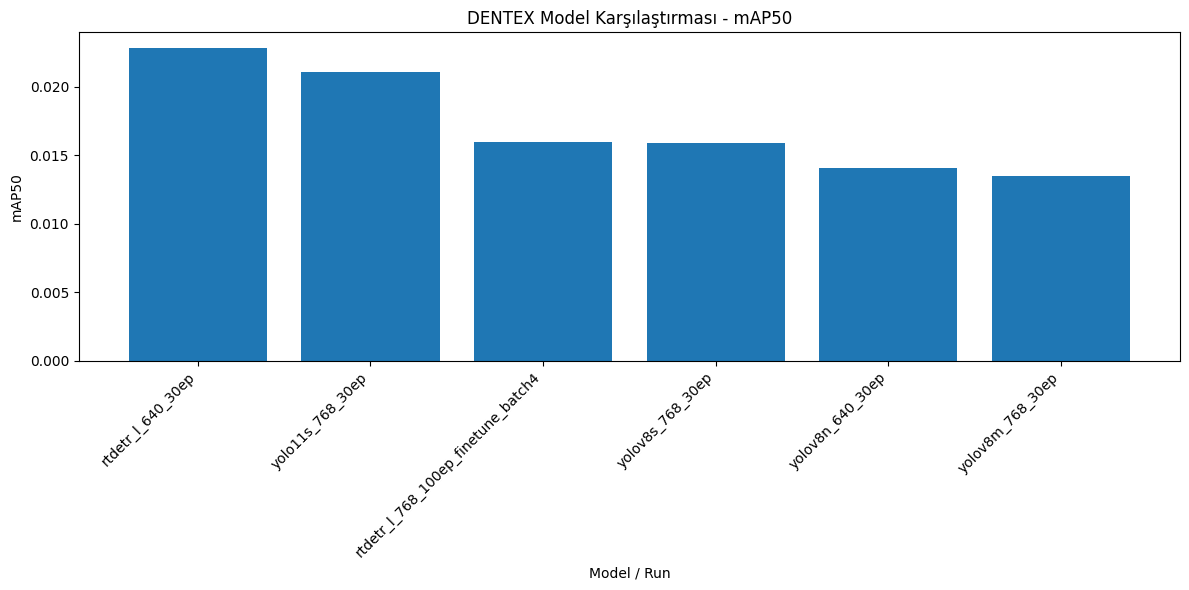

In [57]:
plot_df = df_dentex_comparison.copy()

plt.figure(figsize=(12, 6))
plt.bar(plot_df["run_name"], plot_df["mAP50"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Model / Run")
plt.ylabel("mAP50")
plt.title("DENTEX Model Karşılaştırması - mAP50")
plt.tight_layout()
plt.show()

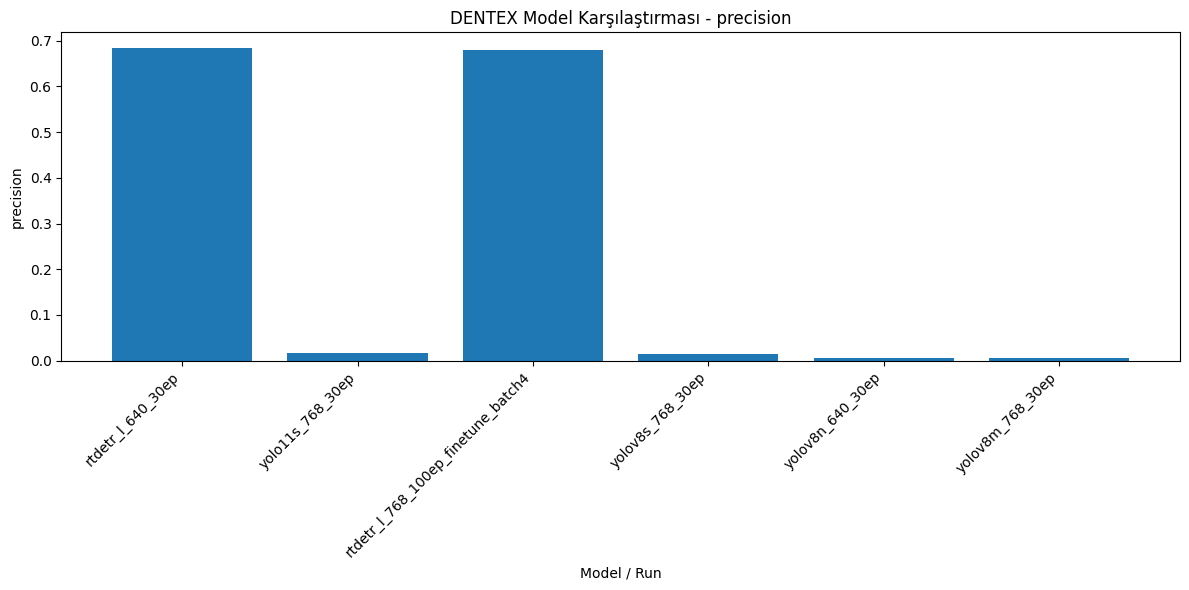

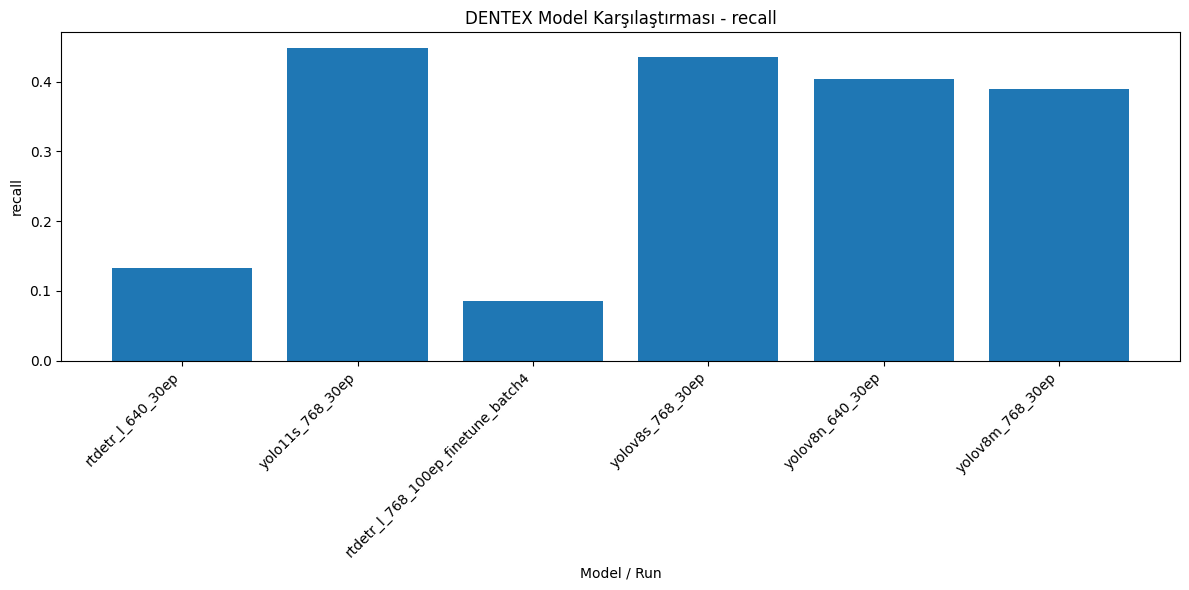

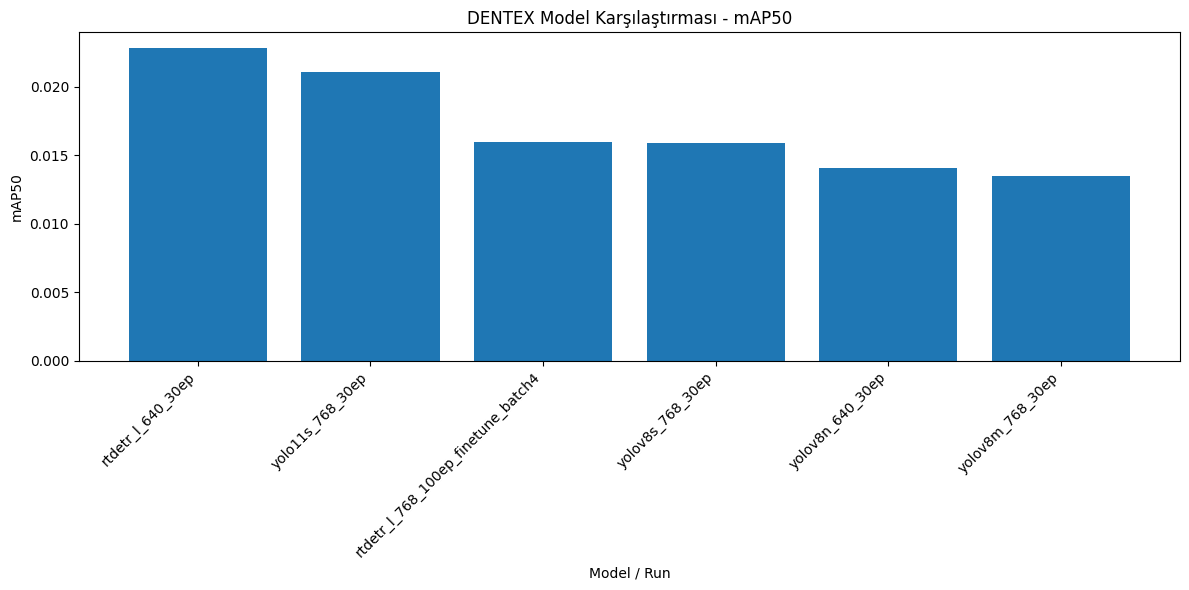

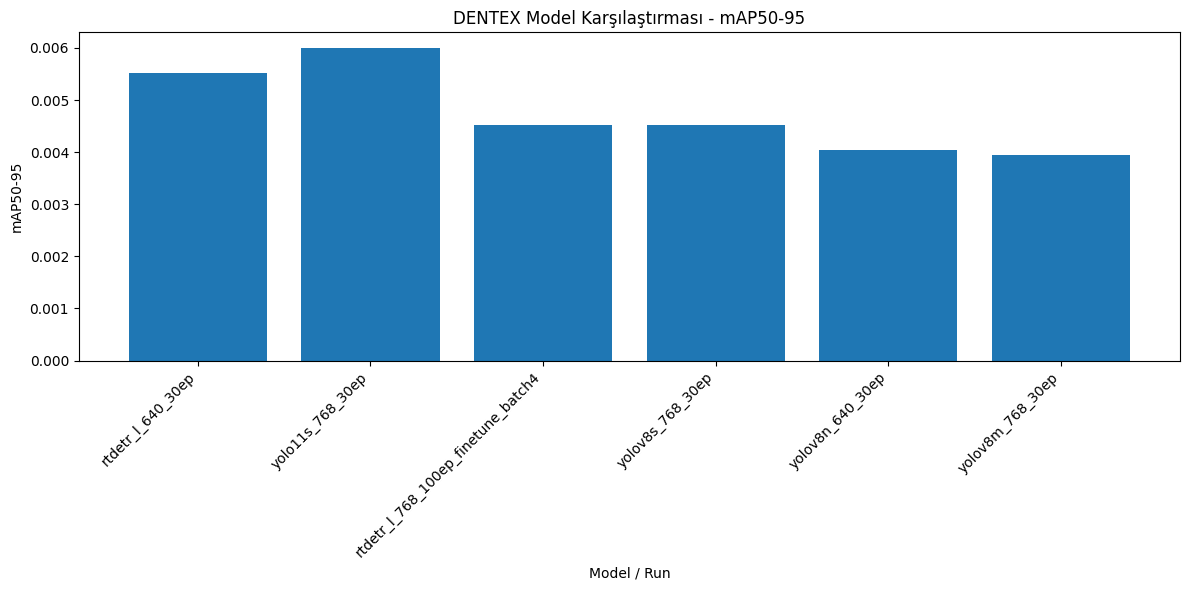

In [58]:
plot_df = df_dentex_comparison.copy()

metrics = ["precision", "recall", "mAP50", "mAP50-95"]

for metric in metrics:
    plt.figure(figsize=(12, 6))
    plt.bar(plot_df["run_name"], plot_df[metric])
    plt.xticks(rotation=45, ha="right")
    plt.xlabel("Model / Run")
    plt.ylabel(metric)
    plt.title(f"DENTEX Model Karşılaştırması - {metric}")
    plt.tight_layout()
    plt.show()

In [59]:
best_map50 = df_dentex_comparison.iloc[0]["mAP50"]
best_run = df_dentex_comparison.iloc[0]["run_name"]

comparison_rows = []

for _, row in df_dentex_comparison.iterrows():
    diff = best_map50 - row["mAP50"]

    comparison_rows.append({
        "run_name": row["run_name"],
        "model": row["model"],
        "mAP50": row["mAP50"],
        "difference_from_best_mAP50": round(diff, 6),
        "selected_best": row["run_name"] == best_run
    })

df_best_comparison = pd.DataFrame(comparison_rows)

df_best_comparison

,run_name,model,mAP50,difference_from_best_mAP50,selected_best
0,rtdetr_l_640_30ep,RT-DETR-l,0.022853,0.000000,True
1,yolo11s_768_30ep,YOLO11s,0.021067,0.001786,False
2,rtdetr_l_768_100ep_finetune_batch4,RT-DETR-l,0.015950,0.006903,False
3,yolov8s_768_30ep,YOLOv8s,0.015872,0.006981,False
4,yolov8n_640_30ep,YOLOv8n,0.014097,0.008756,False
5,yolov8m_768_30ep,YOLOv8m,0.013507,0.009346,False


In [60]:
best = df_dentex_comparison.iloc[0]
second = df_dentex_comparison.iloc[1]

comment = f"""
DENTEX veri seti üzerinde gerçekleştirilen ilk tur model karşılaştırmasında en iyi sonuç
{best['model']} modeli ile elde edilmiştir. {best['run_name']} deneyinde model,
{int(best['imgsz'])} görüntü boyutu, {int(best['epochs'])} epoch ve batch={int(best['batch'])}
ayarlarıyla eğitilmiş; test setinde precision={best['precision']:.4f}, recall={best['recall']:.4f},
mAP50={best['mAP50']:.4f} ve mAP50-95={best['mAP50-95']:.4f} değerlerine ulaşmıştır.

Daha yüksek görüntü boyutu ve daha uzun eğitim süresiyle gerçekleştirilen RT-DETR-l fine-tune denemesi,
ilk tur RT-DETR-l modelinden daha düşük mAP50 sonucu vermiştir. Bu nedenle final DENTEX modeli olarak
{best['run_name']} deneyi seçilmiştir.

Genel olarak DENTEX veri setinde tüm modellerin mAP değerleri düşük kalmıştır. Bu durum, panoramik X-ray
görüntülerinde çürük ve periapikal lezyon gibi küçük patolojik bulguların düşük görünürlüğü, sınıf dengesizliği
ve anotasyonların çürüğün piksel düzeyindeki sınırından çok hastalık bulgusu taşıyan diş/bölgeyi temsil etmesiyle
ilişkilendirilebilir.
"""

print(comment)


DENTEX veri seti üzerinde gerçekleştirilen ilk tur model karşılaştırmasında en iyi sonuç 
RT-DETR-l modeli ile elde edilmiştir. rtdetr_l_640_30ep deneyinde model,
640 görüntü boyutu, 30 epoch ve batch=4
ayarlarıyla eğitilmiş; test setinde precision=0.6842, recall=0.1331,
mAP50=0.0229 ve mAP50-95=0.0055 değerlerine ulaşmıştır.

Daha yüksek görüntü boyutu ve daha uzun eğitim süresiyle gerçekleştirilen RT-DETR-l fine-tune denemesi,
ilk tur RT-DETR-l modelinden daha düşük mAP50 sonucu vermiştir. Bu nedenle final DENTEX modeli olarak
rtdetr_l_640_30ep deneyi seçilmiştir.

Genel olarak DENTEX veri setinde tüm modellerin mAP değerleri düşük kalmıştır. Bu durum, panoramik X-ray
görüntülerinde çürük ve periapikal lezyon gibi küçük patolojik bulguların düşük görünürlüğü, sınıf dengesizliği
ve anotasyonların çürüğün piksel düzeyindeki sınırından çok hastalık bulgusu taşıyan diş/bölgeyi temsil etmesiyle
ilişkilendirilebilir.

